## Quantization Error Analysis

In [1]:
!pip install -q bitsandbytes>=0.39.0
!pip install git+https://github.com/huggingface/accelerate.git
!pip install git+https://github.com/huggingface/transformers.git

  Cloning https://github.com/huggingface/accelerate.git to /tmp/pip-req-build-51dyrlog
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/accelerate.git /tmp/pip-req-build-51dyrlog
  Resolved https://github.com/huggingface/accelerate.git to commit e203e1ddf33388e22f4a7985ff3103717c0f9181
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/huggingface/transformers.git to /tmp/pip-req-build-_rog7pf5
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git /tmp/pip-req-build-_rog7pf5
  Resolved https://github.com/huggingface/transformers.git to commit 66880ecc9688d67440c42d77d7b64474faf21e18
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.9/842.9 kB 48.7 MB/s eta 0:0

In [2]:
import torch
def absmax_quantization(X):
  ## Calculate the Scale
  scale = 127/torch.max(torch.abs(X))
  ## Quantize
  X_quant = (scale*X).round()
  ## Dequantize
  X_dequant = X_quant/scale
  return X_quant, X_dequant

def zeropoint_quantization(X):
  ## Calculate the value range (denominator)
  x_range = torch.max(X) - torch.min(X)
  x_range = 1 if x_range == 0 else x_range
  ## Calculate the Scale
  scale = 127/x_range
  ## SHift by Zero-point
  zeropoint = (-scale * torch.min(X) - 128).round()
  ## Scale and Round the inputs
  X_quant = torch.clip((X*scale + zeropoint).round(),-128,127)
  ## Dequantize
  X_dequant = (X_quant - zeropoint)/scale
  return X_quant, X_dequant

def Calculate_perplexity(model,text):
  ## Encoding the Text
  encodings = tokenizer(text, return_tensors = 'pt').to(device)

  ## Define the input_)ids and target_ids
  input_ids = encodings['input_ids']
  target_ids = input_ids.clone()
  with torch.no_grad():
    outputs = model(input_ids,labels=target_ids)

  ## Loss Calculation
  neg_log_likelihood = output.loss

  ## Perplexity Calculation
  ppl = torch.exp(neg_log_likelihood)
  return ppl

def generate_text(model,input_text,max_length=50):
  input_ids = tokenizer.encode(input_text,return_tensors='pt').to(device)
  output = model.generate(
      input_ids,
      max_length=max_length,
      do_sample = True,
      top_k = 30,
      attention_mask = input_ids.new_ones(input_ids.shape),
      pad_token_id = tokenizer.eos_token_id
  )
  return tokenizer.decode(output[0],skip_special_tokens=True)

In [3]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("PyTorch CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
PyTorch CUDA version: 12.8
GPU: Tesla T4


In [4]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
torch.manual_seed(42)

## Set the device as 'cpu' for now
device = 'cuda'

## load the model and tokenizer
model_id = 'gpt2'
model = AutoModelForCausalLM.from_pretrained(model_id).to(device)
tokenizer = AutoTokenizer.from_pretrained(model_id)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [5]:
## Printing the Model Size
print(f"Model Size: {model.get_memory_footprint():,} bytes")

Model Size: 497,759,232 bytes


In [6]:
## Extract weights of the first Layer
weights = model.transformer.h[0].attn.c_attn.weight.data

## Quantize the Layer Using the absmax Quantization
weights_abs_quant,_ = absmax_quantization(weights)

## Quantize the layer using the zero point quantization
weights_zp_quant,_ = zeropoint_quantization(weights)

In [7]:
import numpy as np
from copy import deepcopy

In [8]:
## Store the original weights
weights = [param.data.clone() for param in model.parameters()]

## Create a Model to quantize
model_abs = deepcopy(model)

## Quantize all model weights
weights_abs = []
for param in model_abs.parameters():
  _,dequantized = absmax_quantization(param.data)
  param.data = dequantized
  weights_abs.append(dequantized)

## Create a model to quantize
model_zp = deepcopy(model)

## Quantize all model weights
weights_zp = []
for param in model_zp.parameters():
  _,dequantized = zeropoint_quantization(param.data)
  param.data = dequantized
  weights_zp.append(dequantized)


#### Comparision between the Original and Absmax Quantized weights

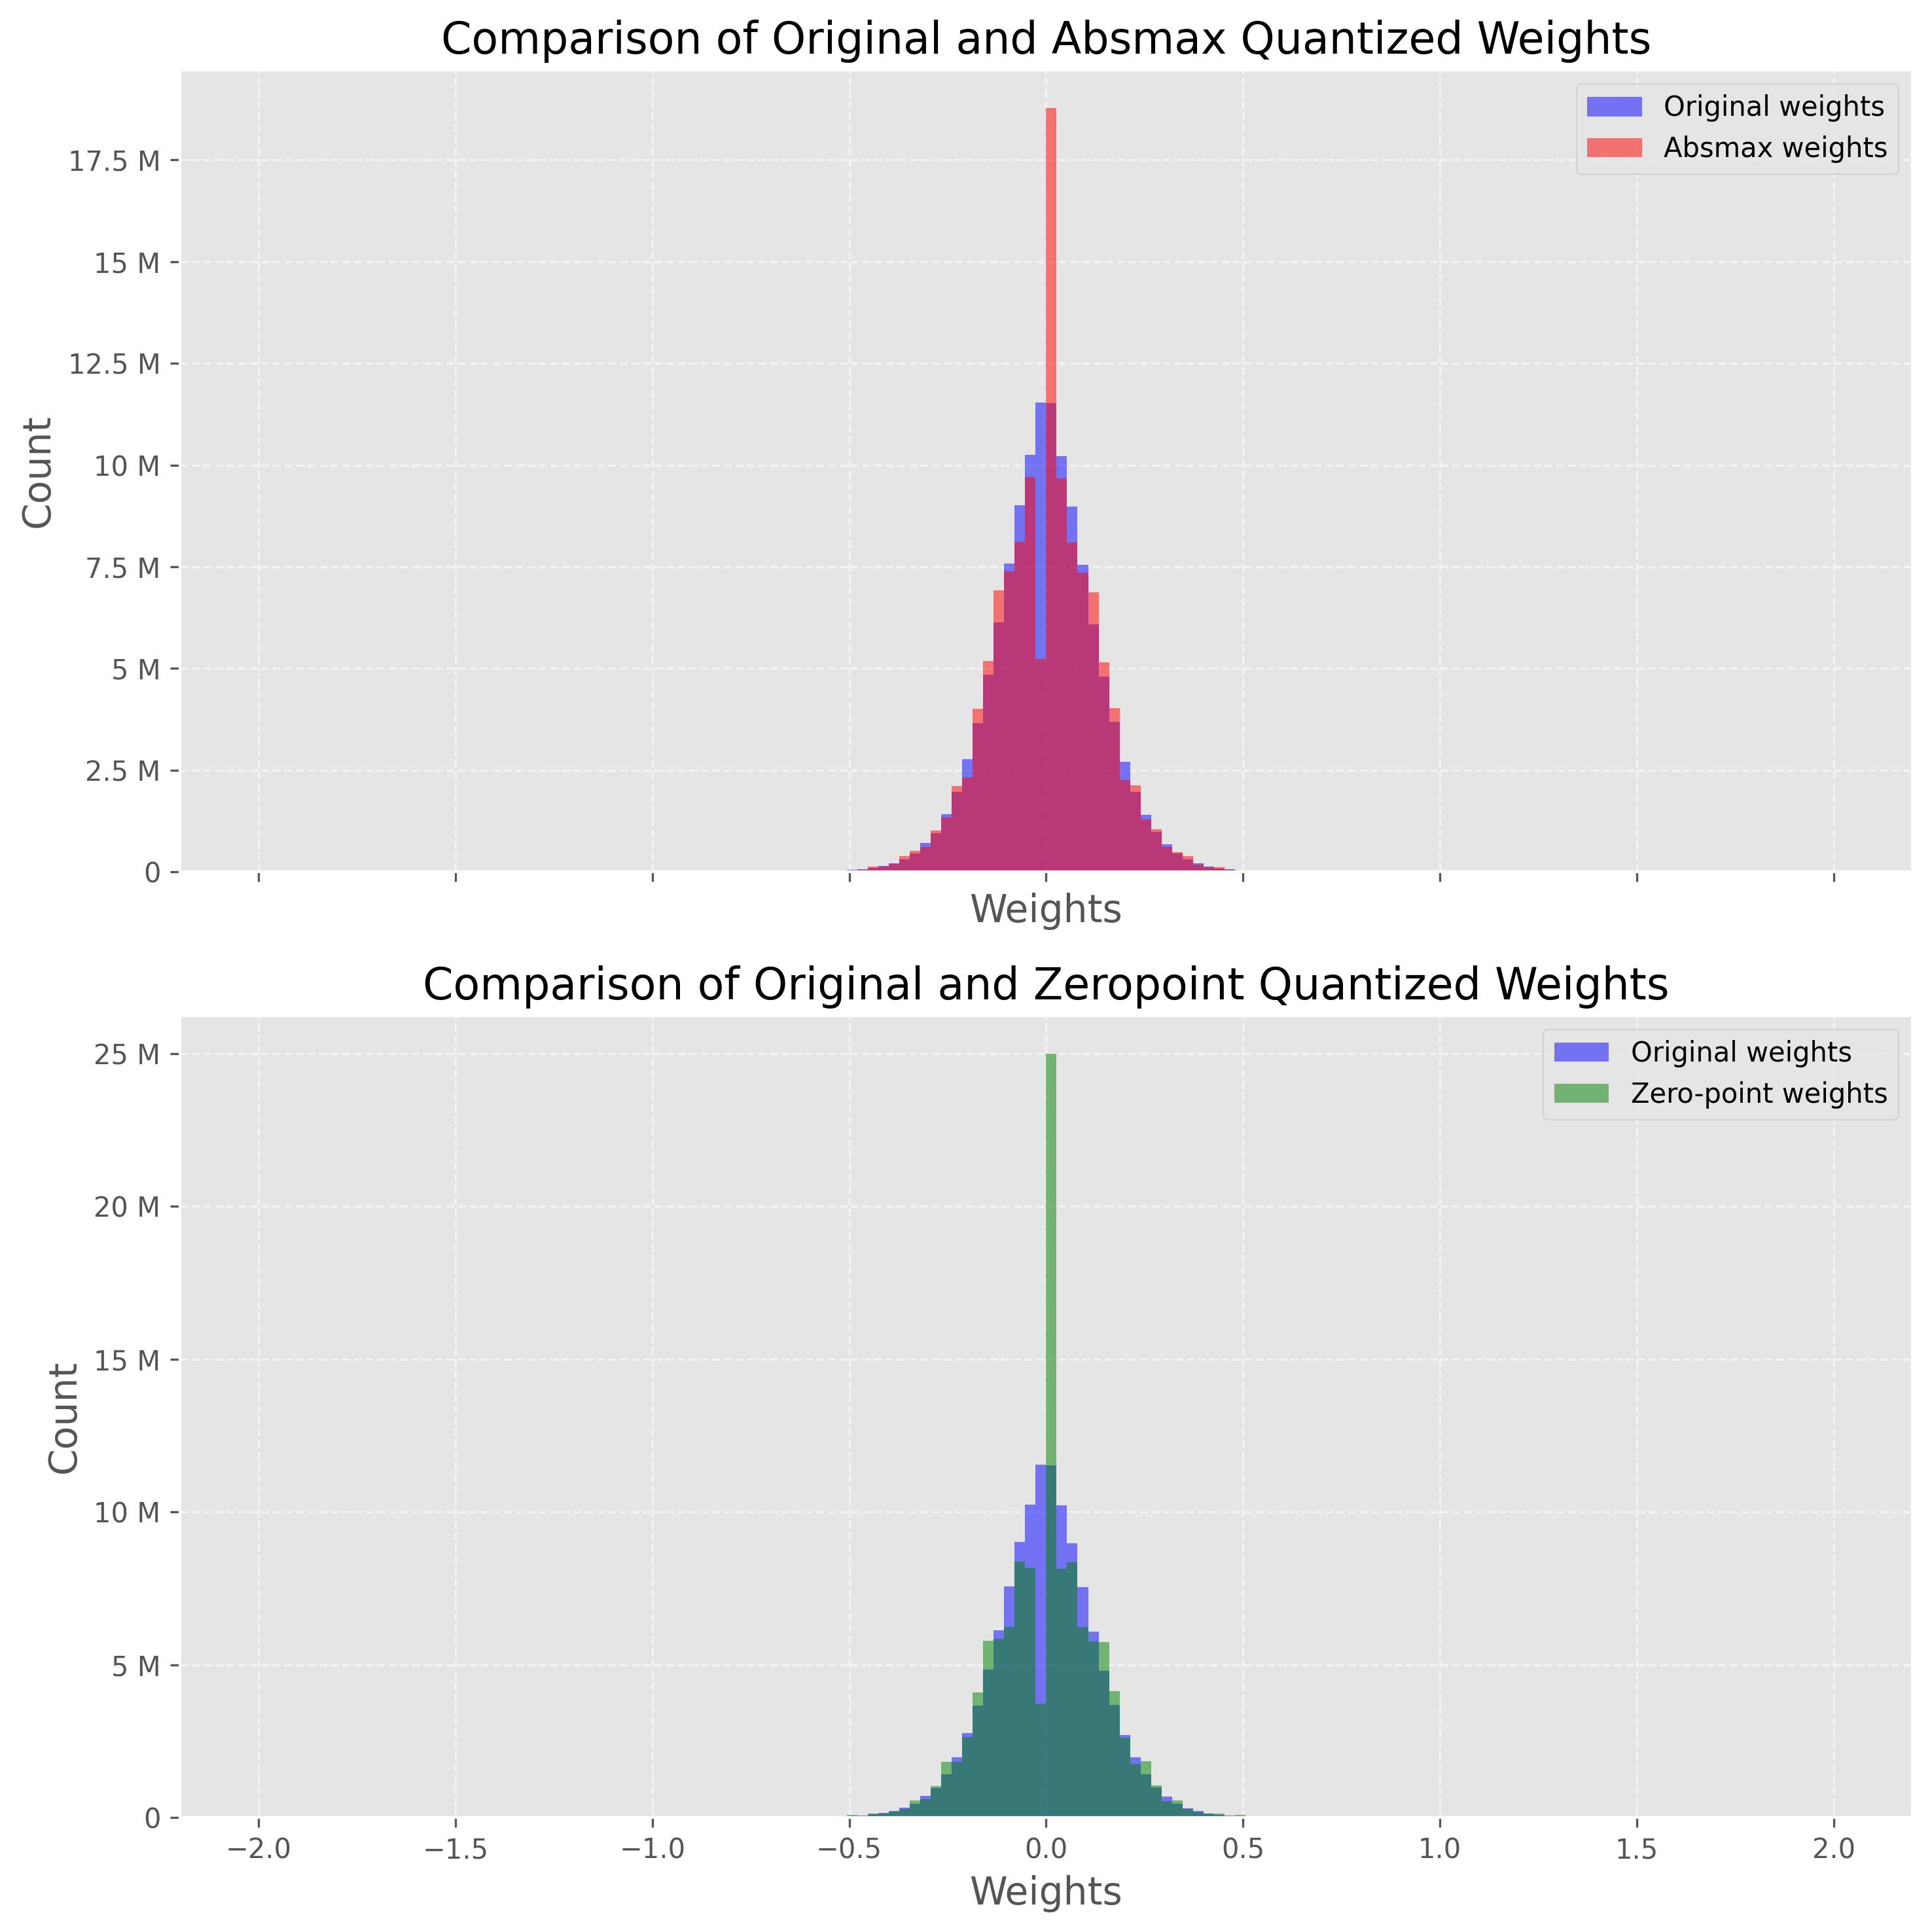

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Flatten weight tensors
weights = np.concatenate([t.cpu().numpy().flatten() for t in weights])
weights_abs = np.concatenate([t.cpu().numpy().flatten() for t in weights_abs])
weights_zp = np.concatenate([t.cpu().numpy().flatten() for t in weights_zp])

# Set background style
plt.style.use('ggplot')

# Create figure and axes
fig, axs = plt.subplots(2, figsize=(10,10), dpi=300, sharex=True)

# Plot the histograms for original and zero-point weights
axs[0].hist(weights, bins=150, alpha=0.5, label='Original weights', color='blue', range=(-2, 2))
axs[0].hist(weights_abs, bins=150, alpha=0.5, label='Absmax weights', color='red', range=(-2, 2))

# Plot the histograms for original and absmax weights
axs[1].hist(weights, bins=150, alpha=0.5, label='Original weights', color='blue', range=(-2, 2))
axs[1].hist(weights_zp, bins=150, alpha=0.5, label='Zero-point weights', color='green', range=(-2, 2))

# Add grid
for ax in axs:
    ax.grid(True, linestyle='--', alpha=0.6)

# Add legend
axs[0].legend()
axs[1].legend()

# Add title and labels
axs[0].set_title('Comparison of Original and Absmax Quantized Weights', fontsize=16)
axs[1].set_title('Comparison of Original and Zeropoint Quantized Weights', fontsize=16)

for ax in axs:
    ax.set_xlabel('Weights', fontsize=14)
    ax.set_ylabel('Count', fontsize=14)
    ax.yaxis.set_major_formatter(ticker.EngFormatter()) # Make y-ticks more human readable

# Improve font
plt.rc('font', size=12)

plt.tight_layout()
plt.show()


### Testing the Same models with the int8 quantization

In [11]:
import torch
from transformers import AutoModelForCausalLM, BitsAndBytesConfig

quant_config = BitsAndBytesConfig(
    load_in_8bit=True
)

model_int8 = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=quant_config,
    device_map="auto"
)

print(f"Model size: {model_int8.get_memory_footprint():,} bytes")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Model size: 242,955,264 bytes


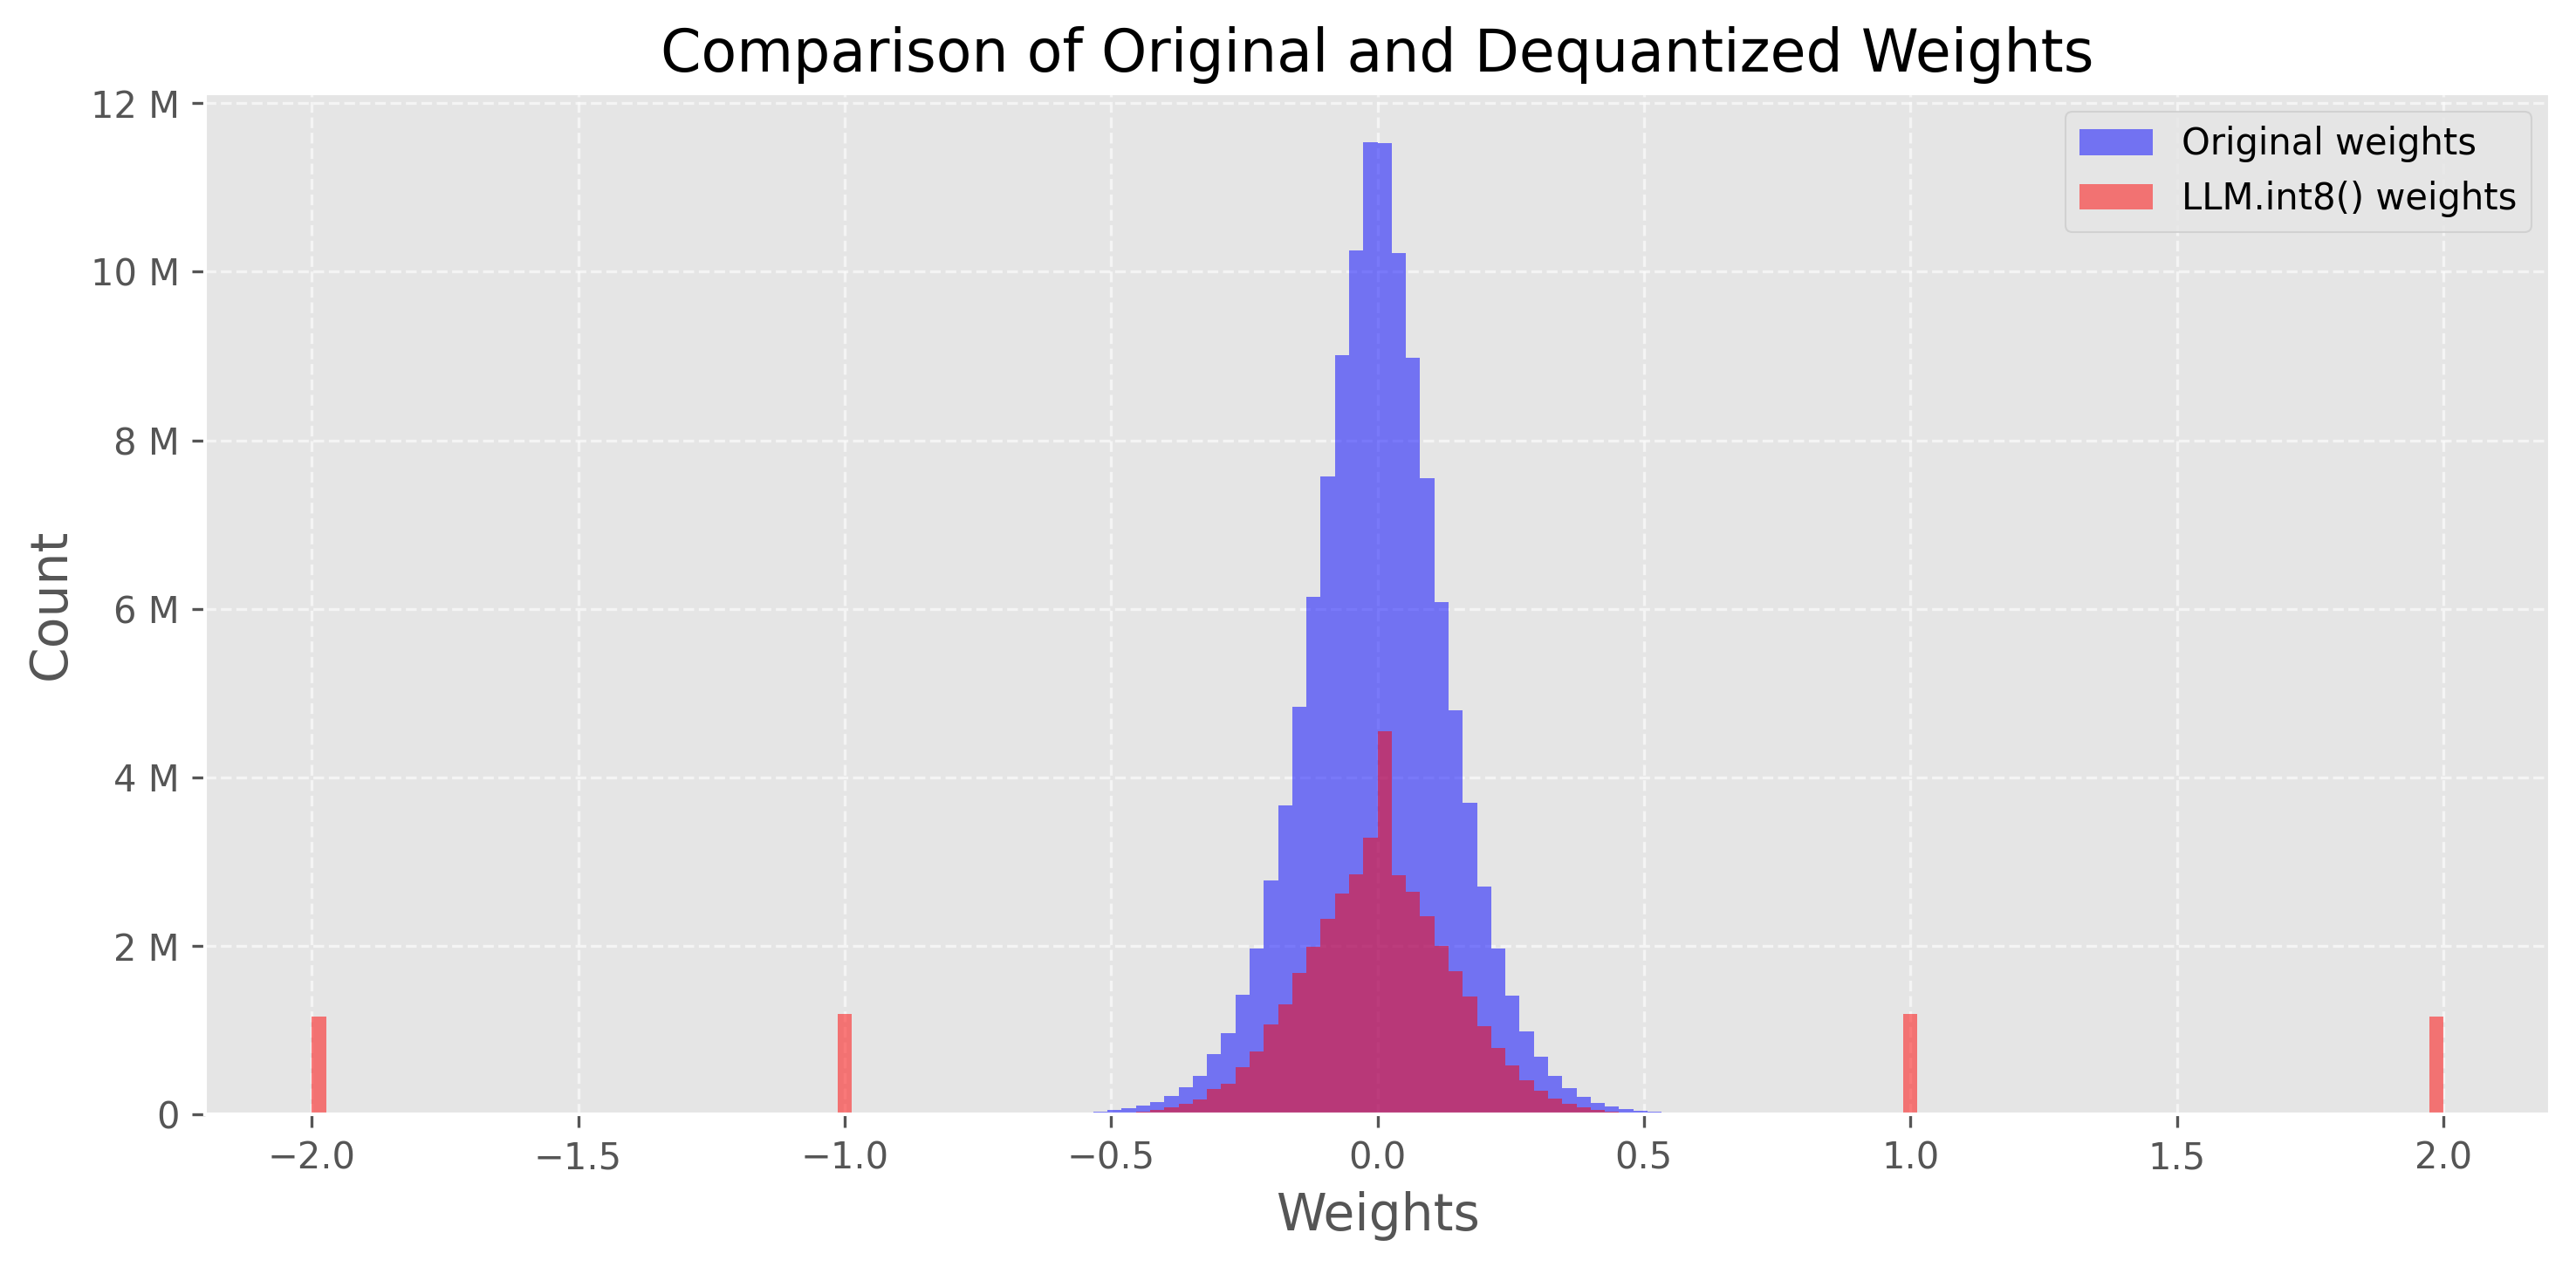

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Flatten weight tensors
weights_int8 = [param.data.clone() for param in model_int8.parameters()]
weights_int8 = np.concatenate([t.cpu().numpy().flatten() for t in weights_int8])

# Set background style
plt.style.use('ggplot')

# Create figure and axis
fig, ax = plt.subplots(figsize=(10,5), dpi=300)

# Plot the histograms
ax.hist(weights, bins=150, alpha=0.5, label='Original weights',
        color='blue', range=(-2, 2))
ax.hist(weights_int8, bins=150, alpha=0.5, label='LLM.int8() weights',
        color='red', range=(-2, 2))

# Add grid
ax.grid(True, linestyle='--', alpha=0.6)

# Add legend
ax.legend()

# Add title and labels
ax.set_title('Comparison of Original and Dequantized Weights', fontsize=16)
ax.set_xlabel('Weights', fontsize=14)
ax.set_ylabel('Count', fontsize=14)
plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())

# Improve font
plt.rc('font', size=12)

plt.tight_layout()
plt.show()


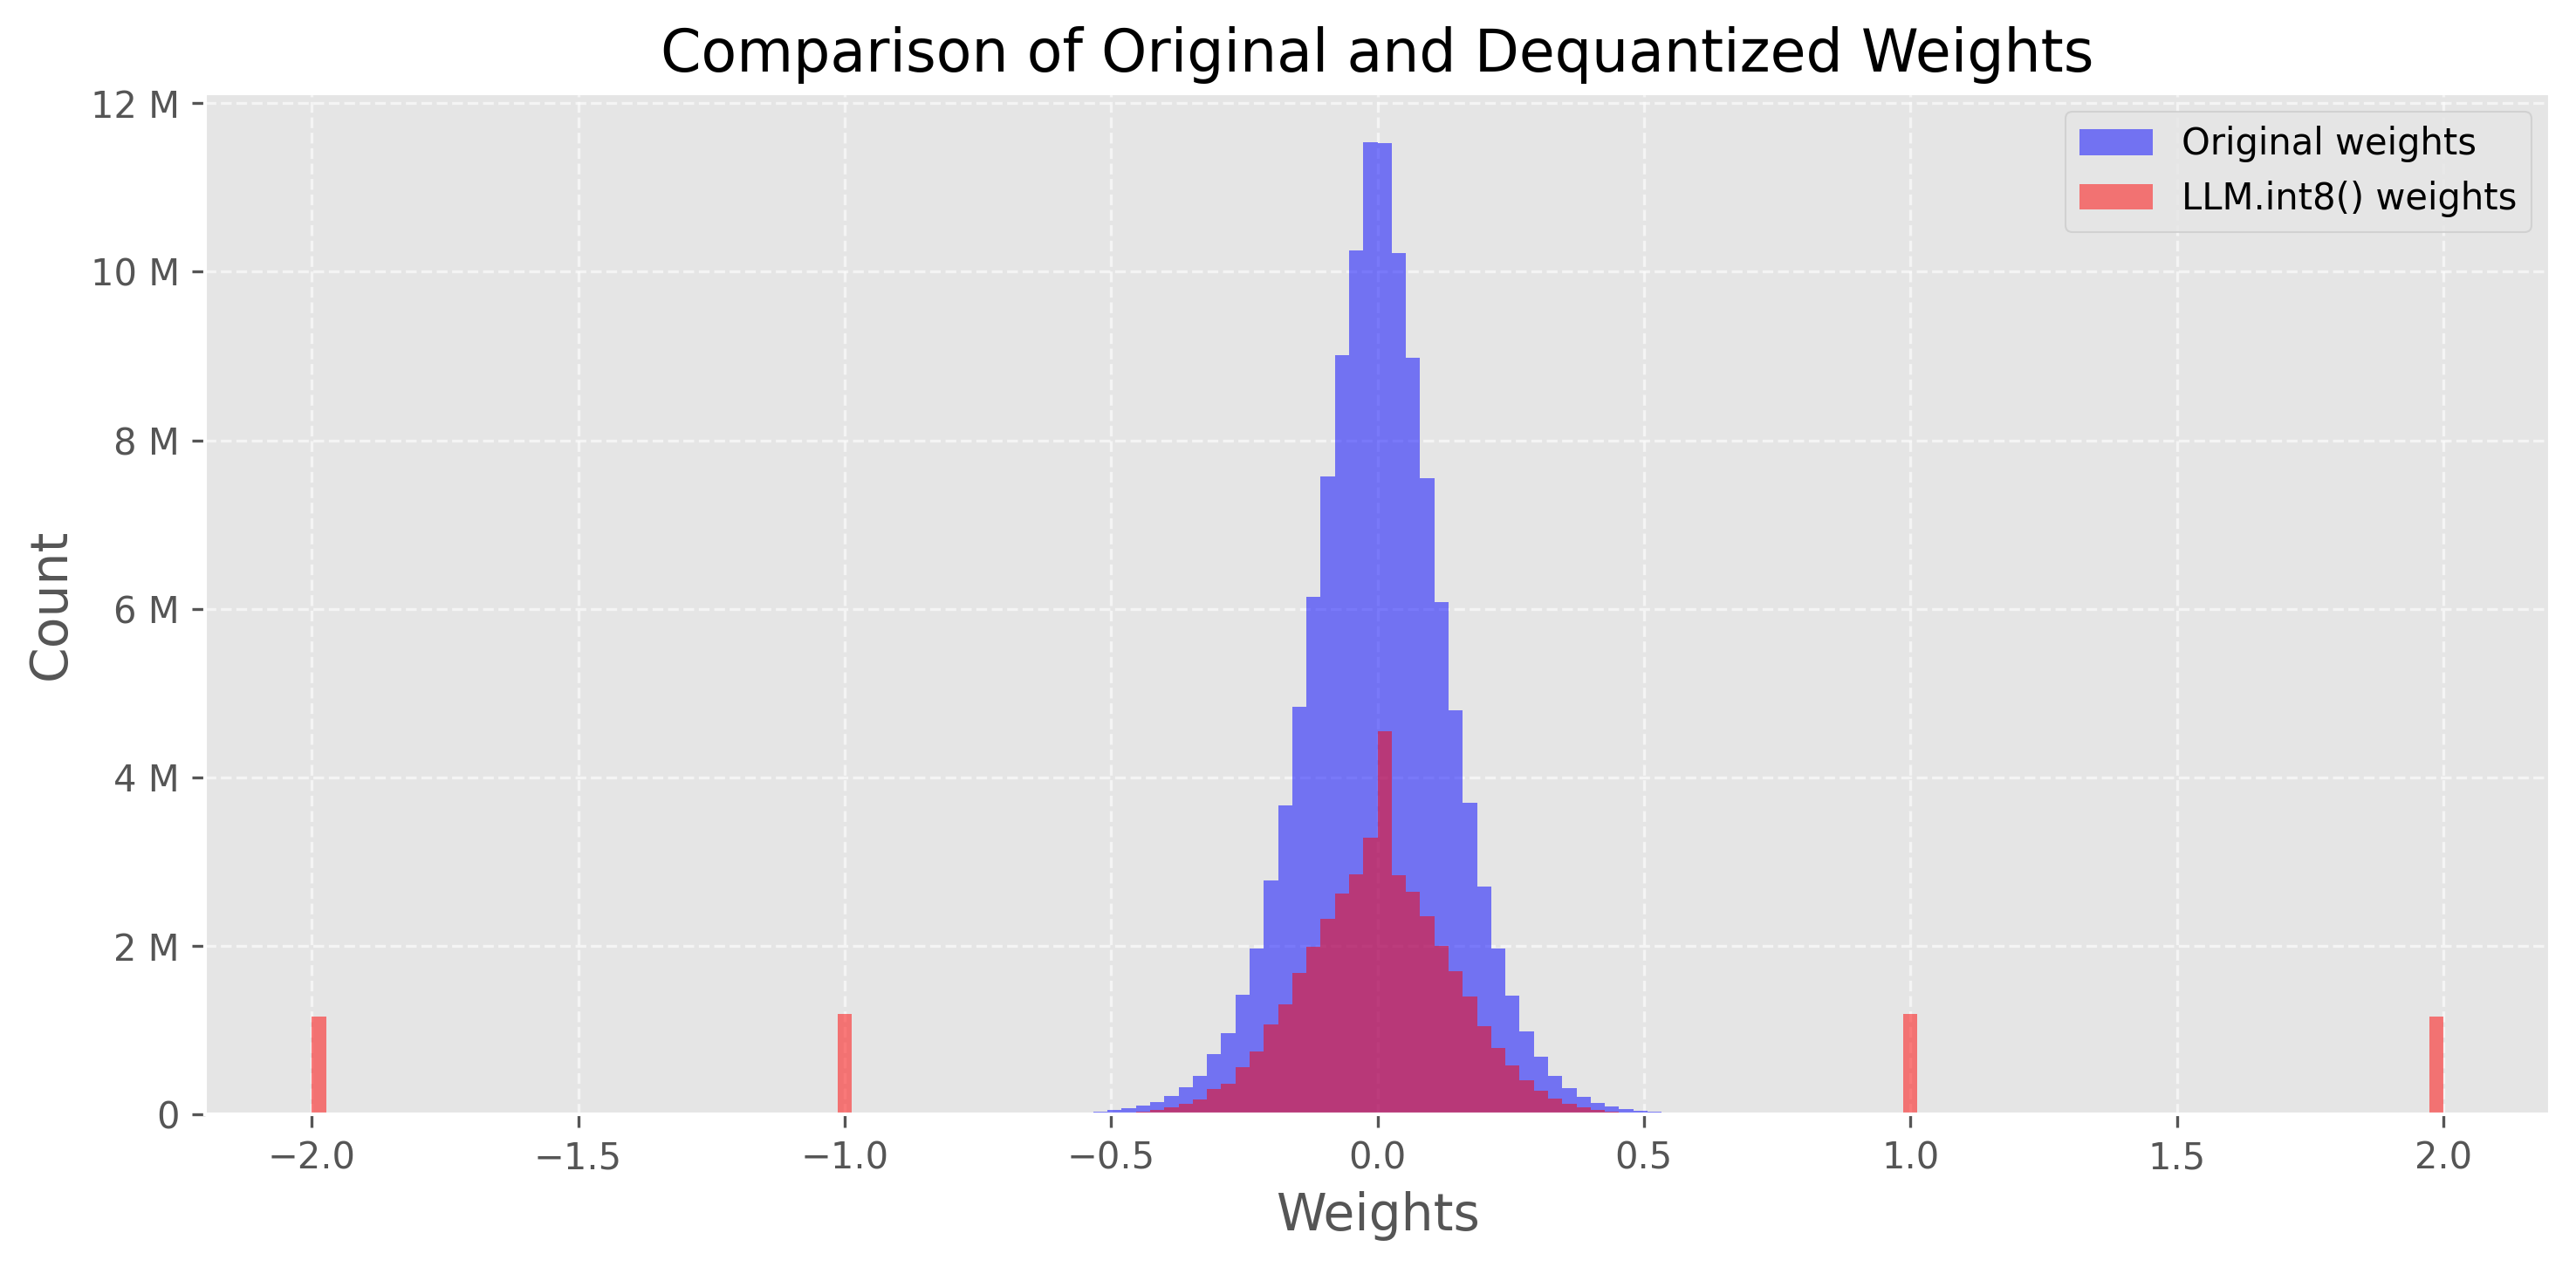

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Flatten weight tensors
weights_int8 = [param.data.clone() for param in model_int8.parameters()]
weights_int8 = np.concatenate([t.cpu().numpy().flatten() for t in weights_int8])

# Set background style
plt.style.use('ggplot')

# Create figure and axis
fig, ax = plt.subplots(figsize=(10,5), dpi=300)

# Plot the histograms
ax.hist(weights, bins=150, alpha=0.5, label='Original weights',
        color='blue', range=(-2, 2))
ax.hist(weights_int8, bins=150, alpha=0.5, label='LLM.int8() weights',
        color='red', range=(-2, 2))

# Add grid
ax.grid(True, linestyle='--', alpha=0.6)

# Add legend
ax.legend()

# Add title and labels
ax.set_title('Comparison of Original and Dequantized Weights', fontsize=16)
ax.set_xlabel('Weights', fontsize=14)
ax.set_ylabel('Count', fontsize=14)
plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())

# Improve font
plt.rc('font', size=12)

plt.tight_layout()
plt.show()